In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

In [2]:
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

In [3]:
train_df.shape

(60000, 785)

In [4]:
test_df.shape

(10000, 785)

In [18]:
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

In [19]:
#NOrmalization
X_train = X_train / 255.0
X_test = X_test / 255.0

In [20]:
#Reshape for CNN
X_train = X_train.reshape(-1, 28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [21]:
#Build CNN model
model = Sequential()

In [22]:
model.add(
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1))
)

In [23]:
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [24]:
model.add(Flatten())

In [25]:
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

In [26]:
model.add(Dense(10, activation='softmax'))

In [27]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         692,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.8415 - loss: 0.4435 - val_accuracy: 0.8865 - val_loss: 0.3229
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8908 - loss: 0.3034 - val_accuracy: 0.8951 - val_loss: 0.2929
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9056 - loss: 0.2591 - val_accuracy: 0.9083 - val_loss: 0.2603
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9174 - loss: 0.2268 - val_accuracy: 0.9060 - val_loss: 0.2577
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9236 - loss: 0.2053 - val_accuracy: 0.9147 - val_loss: 0.2431
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9333 - loss: 0.1798 - val_accuracy: 0.9144 - val_loss: 0.2490
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9391 - loss: 0.1638 - val_accuracy: 0.9113 - val_loss: 0.2538
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9456 -

In [30]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [31]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.92

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1000
           1       0.99      0.99      0.99      1000
           2       0.87      0.90      0.88      1000
           3       0.92      0.95      0.93      1000
           4       0.87      0.91      0.89      1000
           5       0.97      0.98      0.98      1000
           6       0.84      0.71      0.77      1000
           7       0.97      0.93      0.95      1000
           8       0.98      0.98      0.98      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



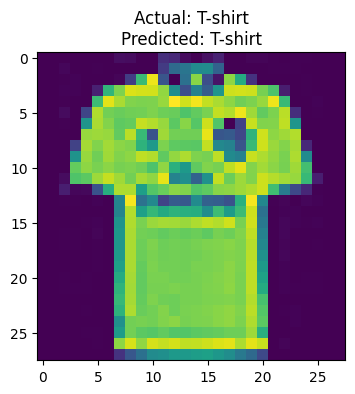

In [40]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

index = 0

plt.figure(figsize=(4,4))
plt.imshow(X_test[index].reshape(28,28))

plt.title("Actual: "+class_names[y_test[index]] + "\nPredicted: " + class_names[y_pred[index]])
plt.show()